In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/hassanamin/textdb3/fake_or_real_news.csv


/kaggle/input/datasets/hassanamin/textdb3/fake_or_real_news.csv
Shape: (6335, 4)

Columns:
Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')

Missing Values:
Unnamed: 0    0
title         0
text          0
label         0
dtype: int64
Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')
Unnamed: 0
title
text
label
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6335 entries, 0 to 6334
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  6335 non-null   int64 
 1   title       6335 non-null   object
 2   text        6335 non-null   object
 3   label       6335 non-null   object
dtypes: int64(1), object(3)
memory usage: 198.1+ KB


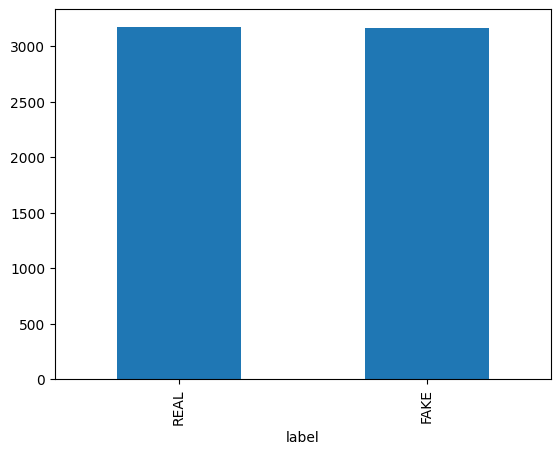

Accuracy: 0.9152139461172741
              precision    recall  f1-score   support

        FAKE       0.91      0.92      0.92       631
        REAL       0.92      0.91      0.91       631

    accuracy                           0.92      1262
   macro avg       0.92      0.92      0.92      1262
weighted avg       0.92      0.92      0.92      1262

[[583  48]
 [ 59 572]]


In [2]:
import pandas as pd
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



df = pd.read_csv('/kaggle/input/datasets/hassanamin/textdb3/fake_or_real_news.csv')

df.head()
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

df.head()
df.sample(5)
print(df.columns)
for col in df.columns:
    print(col)

df.info()
df.isnull().sum()
df.duplicated().sum()
df = df.drop(
    columns=['Unnamed: 0']
)
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")
plt.show()
df["label"].value_counts()

df = df.drop_duplicates()

df = df.dropna()

X = df["title"] + " " + df["text"]

y = df["label"]

X = X.str.lower()

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

from sklearn.feature_extraction.text import TfidfVectorizer



X = df["title"] + " " + df["text"]
y = df["label"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

tfidf = TfidfVectorizer(max_features=5000)

X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))